In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

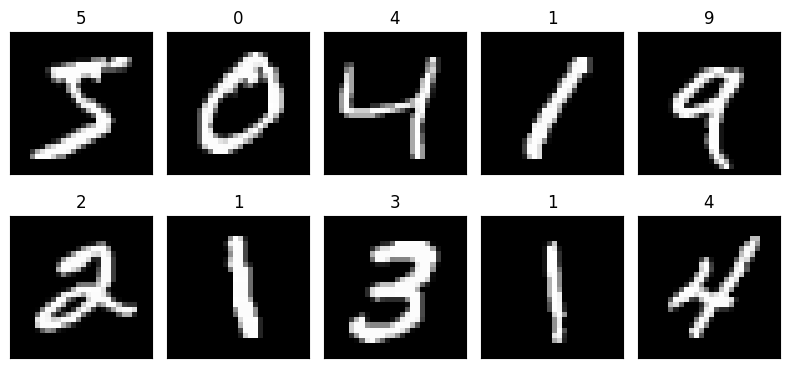

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
digits = fetch_openml('mnist_784', version=1, as_frame=False)

x = digits.data[:7000] 
y = digits.target[:7000]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(8, 4),
                         subplot_kw={'xticks': [], 'yticks': []})

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

for i, ax in enumerate(axes.flat):
    if i < len(x):
        ax.imshow(x[i].reshape(28, 28), cmap='gray')
        ax.set_title(str(y[i]))

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)



In [8]:
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = model , X = x_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

Accuracy :  87.2679 %
Standard Deviation : 1.3925 %


In [9]:
from sklearn . metrics import confusion_matrix
cm = confusion_matrix ( y_test, y_pred)

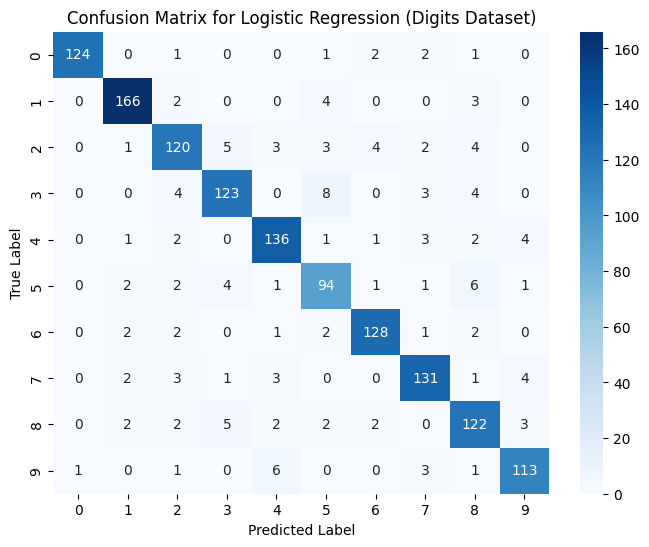

In [10]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix for Logistic Regression (Digits Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

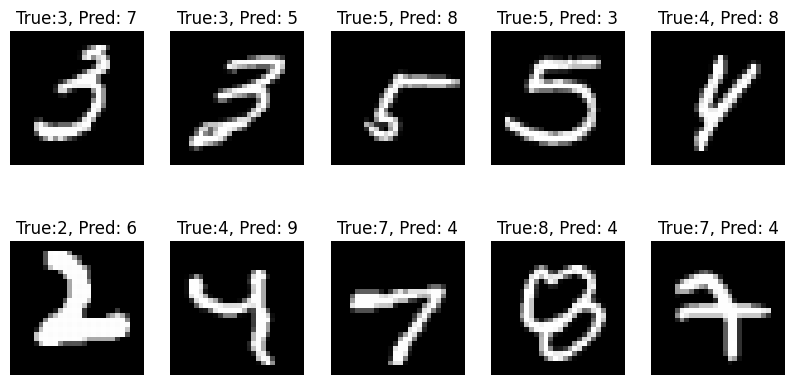

In [11]:
misclassified = np.where(y_test != y_pred)[0]
fig,axes = plt.subplots(2,5,figsize = (10,5))
for i, ax in enumerate(axes.flat):
    idx = misclassified[i]
    ax.imshow(x_test[idx].reshape(28,28),cmap='gray')
    ax.set_title(f"True:{y_test[idx]}, Pred: {y_pred[idx]}")
    ax.axis('off')
plt.show()